05_Deep_Learning_Fundamentals.ipynb

1. Introduction to Deep Learning
2. Neural Network Fundamentals
3. Perceptron
4. From Perceptron to Multi-Layer Perceptron
5. Forward Propagation
6. Activation Functions
   ├── Sigmoid
   ├── Tanh
   ├── ReLU
   ├── Leaky ReLU
   └── Softmax
7. Loss Functions
   ├── MSE
   ├── Binary Cross-Entropy
   └── Categorical Cross-Entropy
8. Computational Graphs
9. Backpropagation
10. Chain Rule
11. Gradient Descent
12. Mini-Batch Gradient Descent
13. Learning Rate
14. Weight Initialization
15. Vanishing & Exploding Gradients
16. Optimizers
   ├── SGD
   ├── Momentum
   ├── AdaGrad
   ├── RMSProp
   └── Adam
17. Regularization
   ├── L1/L2
   ├── Dropout
   └── Early Stopping
18. Batch Normalization
19. Building an MLP from Scratch with NumPy
20. MLP using Scikit-Learn
21. MLP using PyTorch
22. Classification Experiment
23. Regression Experiment
24. Model Diagnostics & Visualization
25. Hyperparameter Experiments
26. Common Failure Modes
27. Practical Deep Learning Workflow
28. Summary
29. Exercises
30. Interview / Viva Questions

# Deep Learning Fundamentals

Deep Learning is a subfield of Machine Learning that uses neural networks with multiple layers to learn increasingly complex representations of data.

A neural network learns a function:

$$
f_\theta : \mathbb{R}^d \rightarrow \mathbb{R}^k
$$

where:

- $d$ is the number of input features,
- $k$ is the number of output values,
- $\theta$ represents all learnable parameters of the network.

A neural network consists primarily of:

1. Input layer
2. Hidden layers
3. Output layer
4. Weights
5. Biases
6. Activation functions
7. Loss function
8. Optimization algorithm

The fundamental learning process is:

$$
\text{Input}
\rightarrow
\text{Forward Propagation}
\rightarrow
\text{Prediction}
\rightarrow
\text{Loss}
\rightarrow
\text{Backpropagation}
\rightarrow
\text{Parameter Update}
$$

This notebook develops these concepts mathematically and implements important components from scratch before using deep-learning frameworks.

## 1. What is Deep Learning?

Traditional machine learning often depends heavily on manually designed features.

For example, a classical image classifier might use:

$$
\text{Image}
\rightarrow
\text{Hand-Crafted Features}
\rightarrow
\text{ML Model}
\rightarrow
\text{Prediction}
$$

Deep learning attempts to learn useful representations automatically:

$$
\text{Raw Data}
\rightarrow
\text{Learned Representation}
\rightarrow
\text{Prediction}
$$

A deep neural network composes many functions:

$$
f(x)
=
f_L(
f_{L-1}(
\cdots
f_2(
f_1(x)
)
\cdots
)
)
$$

Each layer transforms its input into a new representation.

The central idea is therefore **hierarchical representation learning**.

## 2. The Artificial Neuron

The basic computational unit of a neural network is a neuron.

Given an input vector:

$$
x =
\begin{bmatrix}
x_1\\
x_2\\
\vdots\\
x_d
\end{bmatrix}
$$

and weights:

$$
w =
\begin{bmatrix}
w_1\\
w_2\\
\vdots\\
w_d
\end{bmatrix}
$$

the neuron first computes a weighted sum:

$$
z = w^T x + b
$$

where:

- $w$ = weights
- $x$ = input
- $b$ = bias
- $z$ = pre-activation

An activation function $\phi$ is then applied:

$$
a = \phi(z)
$$

Therefore:

$$
a = \phi(w^T x+b)
$$

This equation is the fundamental building block of a neural network.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

x = np.array([2.0, 3.0])

w = np.array([0.5, -0.2])

b = 0.1

z = np.dot(w, x) + b

print("Input:", x)
print("Weights:", w)
print("Bias:", b)
print("Pre-activation:", z)

Input: [2. 3.]
Weights: [ 0.5 -0.2]
Bias: 0.1
Pre-activation: 0.5


## 3. The Perceptron

The perceptron is one of the earliest neural-network models.

It computes:

$$
z = w^T x+b
$$

and applies a step function:

$$
\hat{y}
=
\begin{cases}
1 & z \geq 0\\
0 & z < 0
\end{cases}
$$

The decision boundary is therefore:

$$
w^T x+b=0
$$

For two features:

$$
w_1x_1+w_2x_2+b=0
$$

which represents a straight line.

Thus, a single perceptron can only learn linearly separable decision boundaries.

In [2]:
def step_function(z):
    return np.where(z >= 0, 1, 0)


def perceptron(x, weights, bias):
    z = np.dot(x, weights) + bias
    return step_function(z)


x = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

weights = np.array([1.0, 1.0])
bias = -1.5

predictions = perceptron(x, weights, bias)

print(predictions)

[0 0 0 1]


## 4. Why Do We Need Hidden Layers?

A single perceptron can only represent linear decision boundaries.

For example, the AND function is linearly separable:

| $x_1$ | $x_2$ | $y$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 0 |
| 1 | 0 | 0 |
| 1 | 1 | 1 |

However, XOR is not linearly separable:

| $x_1$ | $x_2$ | $y$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

This motivates the use of multiple layers.

A simple multilayer neural network is:

$$
x
\rightarrow
\text{Hidden Layer}
\rightarrow
\text{Output Layer}
$$

The hidden layers allow the network to construct nonlinear representations.

## 5. Forward Propagation

Consider a network with one hidden layer.

The first layer computes:

$$
z^{(1)}
=
W^{(1)}x+b^{(1)}
$$

The activation is:

$$
a^{(1)}
=
\phi(z^{(1)})
$$

The output layer computes:

$$
z^{(2)}
=
W^{(2)}a^{(1)}+b^{(2)}
$$

and:

$$
\hat{y}
=
g(z^{(2)})
$$

Therefore the complete forward pass is:

$$
\boxed{
\hat{y}
=
g
\left(
W^{(2)}
\phi
\left(
W^{(1)}x+b^{(1)}
\right)
+b^{(2)}
\right)
}
$$

This composition of functions is what gives neural networks their expressive power.

In [3]:
def relu(z):
    return np.maximum(0, z)


# Input
x = np.array([1.0, 2.0])

# Hidden layer
W1 = np.array([
    [0.5, -0.3],
    [0.8,  0.2],
    [-0.4, 0.7]
])

b1 = np.array([0.1, -0.2, 0.3])

# Output layer
W2 = np.array([0.6, -0.5, 0.4])
b2 = 0.2

# Forward propagation
z1 = W1 @ x + b1
a1 = relu(z1)

z2 = W2 @ a1 + b2

print("z1:", z1)
print("a1:", a1)
print("Output:", z2)

z1: [2.77555756e-17 1.00000000e+00 1.30000000e+00]
a1: [2.77555756e-17 1.00000000e+00 1.30000000e+00]
Output: 0.21999999999999986


## 6. Activation Functions

Without nonlinear activation functions, stacking multiple linear layers would still produce a linear transformation.

Suppose:

$$
f(x)=W_1x+b_1
$$

and:

$$
g(x)=W_2f(x)+b_2
$$

Then:

$$
g(f(x))
=
W_2(W_1x+b_1)+b_2
$$

which can be rearranged as:

$$
g(f(x))
=
(W_2W_1)x+(W_2b_1+b_2)
$$

Therefore:

$$
\boxed{
\text{Linear} \circ \text{Linear}
=
\text{Linear}
}
$$

Nonlinear activation functions are therefore essential for deep neural networks.

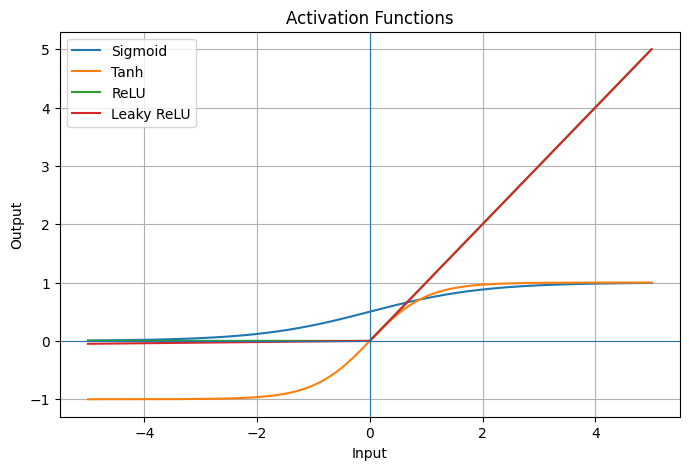

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)


def relu(x):
    return np.maximum(0, x)


def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)


x = np.linspace(-5, 5, 500)

plt.figure(figsize=(8, 5))

plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, tanh(x), label="Tanh")
plt.plot(x, relu(x), label="ReLU")
plt.plot(x, leaky_relu(x), label="Leaky ReLU")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(True)

plt.show()

## 7. Important Activation Functions

### Sigmoid

$$
\sigma(x)
=
\frac{1}{1+e^{-x}}
$$

Its derivative is:

$$
\sigma'(x)
=
\sigma(x)(1-\sigma(x))
$$

It produces values in:

$$
(0,1)
$$

and is commonly associated with binary classification output layers.

---

### Tanh

$$
\tanh(x)
=
\frac{e^x-e^{-x}}
{e^x+e^{-x}}
$$

Its output range is:

$$
(-1,1)
$$

---

### ReLU

$$
\operatorname{ReLU}(x)
=
\max(0,x)
$$

Derivative:

$$
\operatorname{ReLU}'(x)
=
\begin{cases}
1 & x>0\\
0 & x<0
\end{cases}
$$

ReLU is widely used in hidden layers because it is computationally simple and helps reduce some gradient-related problems associated with saturating activations.

---

### Leaky ReLU

$$
f(x)
=
\begin{cases}
x & x>0\\
\alpha x & x\leq0
\end{cases}
$$

where $\alpha$ is a small positive constant.

## 8. Softmax

For a multiclass classification problem with $K$ classes, softmax converts logits into probabilities.

For logit $z_i$:

$$
\operatorname{softmax}(z_i)
=
\frac{e^{z_i}}
{\sum_{j=1}^{K}e^{z_j}}
$$

Therefore:

$$
\sum_{i=1}^{K}p_i=1
$$

A numerically stable implementation subtracts the maximum logit:

$$
\operatorname{softmax}(z_i)
=
\frac{e^{z_i-\max(z)}}
{\sum_j e^{z_j-\max(z)}}
$$

This prevents unnecessarily large exponentials.

In [5]:
def softmax(z):
    z = z - np.max(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z)


logits = np.array([2.5, 1.0, 0.2])

probabilities = softmax(logits)

print("Logits:", logits)
print("Probabilities:", probabilities)
print("Sum:", probabilities.sum())

Logits: [2.5 1.  0.2]
Probabilities: [0.75563572 0.16860512 0.07575916]
Sum: 0.9999999999999998


## 9. Loss Functions

A neural network needs a way to measure how wrong its predictions are.

This is the role of the loss function.

For a dataset:

$$
\mathcal{D}
=
\{(x_i,y_i)\}_{i=1}^{n}
$$

the empirical loss can be written as:

$$
J(\theta)
=
\frac{1}{n}
\sum_{i=1}^{n}
L(f_\theta(x_i),y_i)
$$

where:

- $L$ is the individual loss,
- $f_\theta$ is the neural network,
- $\theta$ represents all parameters.

The optimization problem is:

$$
\boxed{
\theta^*
=
\arg\min_\theta J(\theta)
}
$$

## 10. Mean Squared Error

For regression:

$$
L(y,\hat{y})
=
(y-\hat{y})^2
$$

The dataset-level MSE is:

$$
\operatorname{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
$$

MSE strongly penalizes large errors because the error is squared.

In [6]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


y_true = np.array([3.0, 5.0, 7.0])
y_pred = np.array([2.5, 5.5, 6.0])

print("MSE:", mse(y_true, y_pred))

MSE: 0.5


## 11. Binary Cross-Entropy

For binary classification:

$$
L(y,\hat{p})
=
-
\left[
y\log(\hat{p})
+
(1-y)\log(1-\hat{p})
\right]
$$

The average loss is:

$$
J
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i\log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
$$

Binary cross-entropy is particularly suitable when the output represents a probability.

In [7]:
def binary_cross_entropy(y_true, y_prob):
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)

    return -np.mean(
        y_true * np.log(y_prob)
        + (1 - y_true) * np.log(1 - y_prob)
    )


y_true = np.array([1, 0, 1, 1])
y_prob = np.array([0.9, 0.2, 0.8, 0.7])

print("Binary Cross-Entropy:", binary_cross_entropy(y_true, y_prob))

Binary Cross-Entropy: 0.22708064055624455


## 12. Gradient Descent

Neural networks generally learn by minimizing the loss function.

Suppose the model parameters are represented by:

$$
\theta
$$

and the loss is:

$$
J(\theta)
$$

Gradient descent updates the parameters according to:

$$
\boxed{
\theta_{t+1}
=
\theta_t
-
\eta\nabla_\theta J(\theta_t)
}
$$

where:

- $\eta$ is the learning rate,
- $\nabla_\theta J$ is the gradient of the loss.

The gradient points in the direction of greatest increase of the loss.

Therefore, we move in the opposite direction:

$$
-\nabla_\theta J
$$

to reduce the loss.

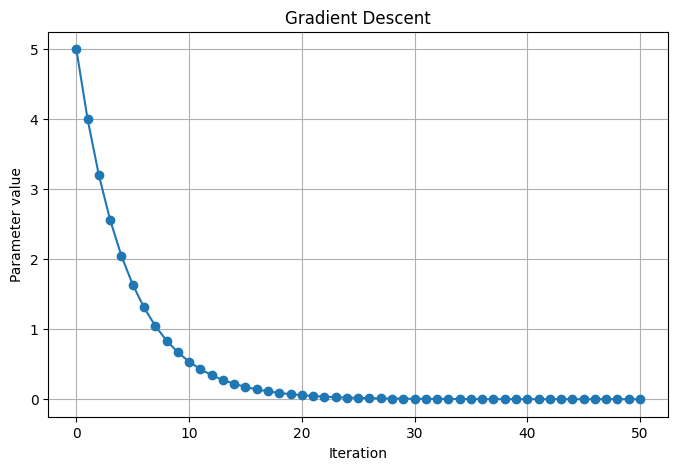

In [8]:
def gradient_descent_quadratic(
    learning_rate=0.1,
    iterations=50
):
    x = 5.0
    history = [x]

    for _ in range(iterations):
        gradient = 2 * x
        x = x - learning_rate * gradient
        history.append(x)

    return history


history = gradient_descent_quadratic()

plt.figure(figsize=(8, 5))
plt.plot(history, marker="o")
plt.title("Gradient Descent")
plt.xlabel("Iteration")
plt.ylabel("Parameter value")
plt.grid(True)
plt.show()

## 13. Computational Graphs

A neural network can be viewed as a computational graph.

For example:

$$
z=wx+b
$$

followed by:

$$
a=\sigma(z)
$$

and:

$$
L=(a-y)^2
$$

The computation is:

$$
w,x
\rightarrow
z
\rightarrow
a
\rightarrow
L
$$

During backpropagation, derivatives are propagated backward through this graph.

Using the chain rule:

$$
\frac{\partial L}{\partial w}
=
\frac{\partial L}{\partial a}
\frac{\partial a}{\partial z}
\frac{\partial z}{\partial w}
$$

This is the mathematical foundation of backpropagation.

## 14. Backpropagation

Backpropagation efficiently computes gradients of the loss with respect to neural-network parameters.

For a simple neuron:

$$
z=wx+b
$$

$$
a=\sigma(z)
$$

$$
L=(a-y)^2
$$

we have:

$$
\frac{\partial L}{\partial a}
=
2(a-y)
$$

and:

$$
\frac{\partial a}{\partial z}
=
a(1-a)
$$

Also:

$$
\frac{\partial z}{\partial w}=x
$$

Therefore:

$$
\boxed{
\frac{\partial L}{\partial w}
=
2(a-y)a(1-a)x
}
$$

Similarly:

$$
\boxed{
\frac{\partial L}{\partial b}
=
2(a-y)a(1-a)
}
$$

These gradients can then be used to update the parameters.

In [9]:
x = 2.0
y = 1.0

w = 0.5
b = 0.1

z = w * x + b
a = sigmoid(z)

loss = (a - y) ** 2

dL_da = 2 * (a - y)
da_dz = a * (1 - a)
dz_dw = x
dz_db = 1

dL_dw = dL_da * da_dz * dz_dw
dL_db = dL_da * da_dz * dz_db

print("Prediction:", a)
print("Loss:", loss)
print("dL/dw:", dL_dw)
print("dL/db:", dL_db)

Prediction: 0.7502601055951177
Loss: 0.062370014857361766
dL/dw: -0.1871749357314132
dL/db: -0.0935874678657066


## 15. Mini-Batch Gradient Descent

Using the entire dataset for every update is called batch gradient descent.

Using one sample at a time gives stochastic gradient descent.

A compromise is mini-batch gradient descent.

For a mini-batch $\mathcal{B}$:

$$
\nabla_\theta J_{\mathcal{B}}
=
\frac{1}{|\mathcal{B}|}
\sum_{i\in\mathcal{B}}
\nabla_\theta L_i
$$

The update becomes:

$$
\theta
\leftarrow
\theta
-
\eta\nabla_\theta J_{\mathcal{B}}
$$

Mini-batch training is the standard approach for modern neural networks because it balances:

- computational efficiency,
- memory usage,
- gradient stability,
- hardware parallelism.

## 16. Learning Rate

The learning rate controls the magnitude of each parameter update:

$$
\theta_{t+1}
=
\theta_t
-
\eta\nabla_\theta J
$$

If $\eta$ is too small:

$$
\text{Learning becomes very slow}
$$

If $\eta$ is too large:

$$
\text{Training may oscillate or diverge}
$$

Therefore, learning-rate selection is one of the most important optimization decisions in deep learning.

## 17. Weight Initialization

Neural networks should not normally initialize all weights to exactly the same value.

Poor initialization can cause neurons to learn identical representations.

Two important initialization strategies are:

### Xavier / Glorot initialization

For approximately symmetric activations:

$$
W
\sim
\mathcal{N}
\left(
0,
\frac{1}{n_{\text{in}}}
\right)
$$

A common Glorot variance is:

$$
\operatorname{Var}(W)
=
\frac{2}
{n_{\text{in}}+n_{\text{out}}}
$$

### He initialization

Designed particularly for ReLU-like activations:

$$
\operatorname{Var}(W)
=
\frac{2}{n_{\text{in}}}
$$

Good initialization helps maintain reasonable activation and gradient scales throughout the network.

## 18. Vanishing and Exploding Gradients

During backpropagation, gradients are repeatedly multiplied through layers.

Conceptually:

$$
\frac{\partial L}
{\partial W^{(1)}}
=
\frac{\partial L}
{\partial a^{(L)}}
\prod_{l=2}^{L}
\frac{\partial a^{(l)}}
{\partial a^{(l-1)}}
\frac{\partial a^{(1)}}
{\partial W^{(1)}}
$$

If these factors are consistently smaller than $1$, gradients may become extremely small:

$$
\boxed{\text{Vanishing gradients}}
$$

If they are consistently larger than $1$, gradients can grow rapidly:

$$
\boxed{\text{Exploding gradients}}
$$

These problems motivated techniques such as:

- better initialization,
- ReLU-family activations,
- normalization,
- residual connections,
- appropriate optimizers,
- gradient clipping.

## 19. Optimizers

Basic SGD uses:

$$
\theta_{t+1}
=
\theta_t
-
\eta g_t
$$

where:

$$
g_t=\nabla_\theta J(\theta_t)
$$

Modern optimizers modify this update.

Important optimizers include:

1. SGD
2. Momentum
3. AdaGrad
4. RMSProp
5. Adam

Adam combines ideas related to momentum and adaptive learning rates.

Its first-moment estimate is:

$$
m_t
=
\beta_1m_{t-1}
+
(1-\beta_1)g_t
$$

Its second-moment estimate is:

$$
v_t
=
\beta_2v_{t-1}
+
(1-\beta_2)g_t^2
$$

Bias-corrected estimates are:

$$
\hat{m}_t
=
\frac{m_t}{1-\beta_1^t}
$$

$$
\hat{v}_t
=
\frac{v_t}{1-\beta_2^t}
$$

The Adam update is:

$$
\boxed{
\theta_{t+1}
=
\theta_t
-
\eta
\frac{\hat{m}_t}
{\sqrt{\hat{v}_t}+\epsilon}
}
$$

## 20. Regularization

Deep neural networks can have millions or billions of parameters and can therefore overfit.

Common regularization methods include:

### L2 Regularization

$$
J_{\text{reg}}
=
J
+
\lambda
\sum_j w_j^2
$$

### L1 Regularization

$$
J_{\text{reg}}
=
J
+
\lambda
\sum_j |w_j|
$$

### Dropout

During training, neurons are randomly deactivated.

If $m$ is a random mask:

$$
\tilde{a}
=
m\odot a
$$

with appropriate scaling to preserve the expected activation magnitude.

### Early Stopping

Training is stopped when validation performance stops improving.

Regularization attempts to improve generalization rather than simply minimizing training error.

## 21. Batch Normalization

Batch normalization normalizes intermediate activations.

For a mini-batch:

$$
\mu_B
=
\frac{1}{m}
\sum_{i=1}^{m}x_i
$$

and:

$$
\sigma_B^2
=
\frac{1}{m}
\sum_{i=1}^{m}
(x_i-\mu_B)^2
$$

The normalized activation is:

$$
\hat{x}_i
=
\frac{x_i-\mu_B}
{\sqrt{\sigma_B^2+\epsilon}}
$$

The layer then learns scale and shift parameters:

$$
y_i
=
\gamma\hat{x}_i+\beta
$$

Batch normalization can help stabilize optimization and allow effective training of deeper networks.

# 22. Building a Neural Network from Scratch

Before using PyTorch, we will implement a small neural network using NumPy.

Architecture:

$$
2
\rightarrow
4
\rightarrow
1
$$

That is:

- 2 input features
- 4 hidden neurons
- 1 output neuron

For binary classification:

$$
z^{(1)}
=
W^{(1)}X+b^{(1)}
$$

$$
a^{(1)}
=
\operatorname{ReLU}(z^{(1)})
$$

$$
z^{(2)}
=
W^{(2)}a^{(1)}+b^{(2)}
$$

$$
\hat{y}
=
\sigma(z^{(2)})
$$

In [10]:
def relu_derivative(z):
    return (z > 0).astype(float)


def sigmoid_derivative(a):
    return a * (1 - a)

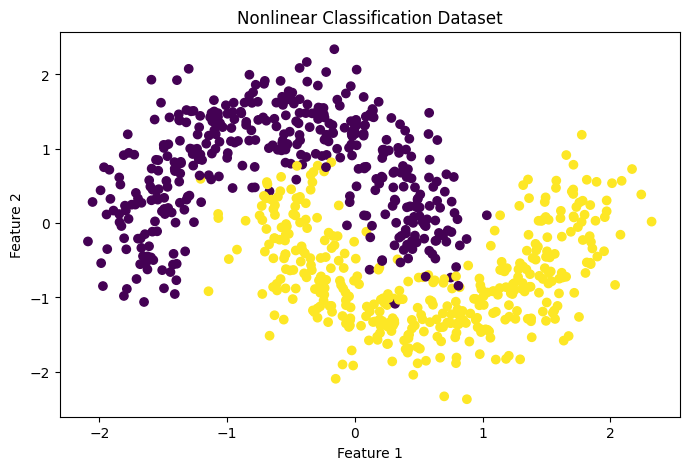

In [11]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_moons(
    n_samples=1000,
    noise=0.2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train
)
plt.title("Nonlinear Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 24. NumPy Neural Network

The network contains:

$$
W_1\in\mathbb{R}^{2\times4}
$$

$$
b_1\in\mathbb{R}^{1\times4}
$$

$$
W_2\in\mathbb{R}^{4\times1}
$$

$$
b_2\in\mathbb{R}^{1\times1}
$$

The forward pass is:

$$
Z_1=XW_1+b_1
$$

$$
A_1=\operatorname{ReLU}(Z_1)
$$

$$
Z_2=A_1W_2+b_2
$$

$$
A_2=\sigma(Z_2)
$$

The binary cross-entropy loss is:

$$
J
=
-\frac{1}{n}
\sum_i
\left[
y_i\log(A_{2,i})
+
(1-y_i)\log(1-A_{2,i})
\right]
$$

In [12]:
n_features = X_train.shape[1]
hidden_units = 4

W1 = np.random.randn(n_features, hidden_units) * np.sqrt(2 / n_features)
b1 = np.zeros((1, hidden_units))

W2 = np.random.randn(hidden_units, 1) * np.sqrt(2 / hidden_units)
b2 = np.zeros((1, 1))


def forward_pass(X):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2

## 25. Backpropagation for the Network

For sigmoid output combined with binary cross-entropy:

$$
\frac{\partial J}{\partial Z_2}
=
A_2-Y
$$

Then:

$$
\frac{\partial J}{\partial W_2}
=
\frac{1}{n}
A_1^T
\frac{\partial J}{\partial Z_2}
$$

and:

$$
\frac{\partial J}{\partial b_2}
=
\frac{1}{n}
\sum_i
\frac{\partial J}{\partial Z_{2,i}}
$$

The hidden-layer gradient is:

$$
\frac{\partial J}{\partial A_1}
=
\frac{\partial J}{\partial Z_2}
W_2^T
$$

Then:

$$
\frac{\partial J}{\partial Z_1}
=
\frac{\partial J}{\partial A_1}
\odot
\operatorname{ReLU}'(Z_1)
$$

Finally:

$$
\frac{\partial J}{\partial W_1}
=
\frac{1}{n}
X^T
\frac{\partial J}{\partial Z_1}
$$

In [13]:
def binary_cross_entropy_loss(y_true, y_prob):
    eps = 1e-15
    y_prob = np.clip(y_prob, eps, 1 - eps)

    return -np.mean(
        y_true.reshape(-1, 1) * np.log(y_prob)
        +
        (1 - y_true.reshape(-1, 1))
        * np.log(1 - y_prob)
    )


learning_rate = 0.05
epochs = 2000

loss_history = []

Y_train = y_train.reshape(-1, 1)

for epoch in range(epochs):

    # Forward pass
    Z1, A1, Z2, A2 = forward_pass(X_train)

    # Loss
    loss = binary_cross_entropy_loss(Y_train, A2)
    loss_history.append(loss)

    # Backpropagation
    m = X_train.shape[0]

    dZ2 = A2 - Y_train
    dW2 = (A1.T @ dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)

    dW1 = (X_train.T @ dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    # Parameter update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}")

Epoch 0: Loss = 0.7363
Epoch 200: Loss = 0.3481
Epoch 400: Loss = 0.3227
Epoch 600: Loss = 0.3148
Epoch 800: Loss = 0.3069
Epoch 1000: Loss = 0.2991
Epoch 1200: Loss = 0.2920
Epoch 1400: Loss = 0.2857
Epoch 1600: Loss = 0.2805
Epoch 1800: Loss = 0.2767


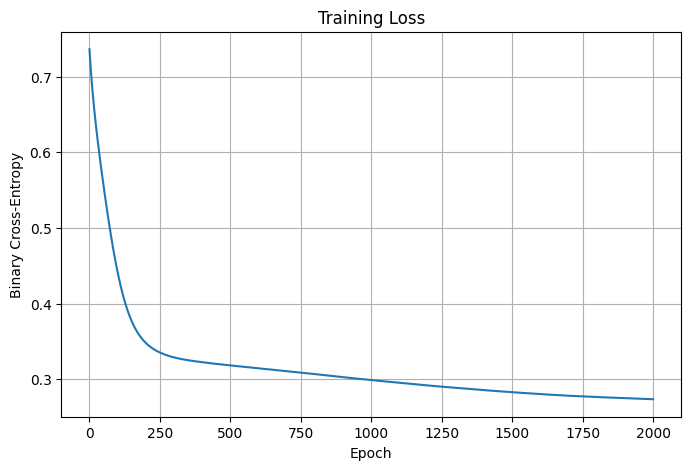

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.grid(True)

plt.show()

## 26. Evaluating the Network

For binary classification:

$$
\hat{y}
=
\begin{cases}
1 & p\geq0.5\\
0 & p<0.5
\end{cases}
$$

We will evaluate:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

_, _, _, test_prob = forward_pass(X_test)

test_pred = (test_prob >= 0.5).astype(int).ravel()

print("Accuracy :", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred))
print("Recall   :", recall_score(y_test, test_pred))
print("F1       :", f1_score(y_test, test_pred))
print("ROC-AUC   :", roc_auc_score(y_test, test_prob.ravel()))

Accuracy : 0.915
Precision: 0.946236559139785
Recall   : 0.88
F1       : 0.9119170984455959
ROC-AUC   : 0.98295


## 27. Decision Boundary

A major advantage of neural networks is their ability to learn nonlinear decision boundaries.

We can visualize the learned function over the feature space.

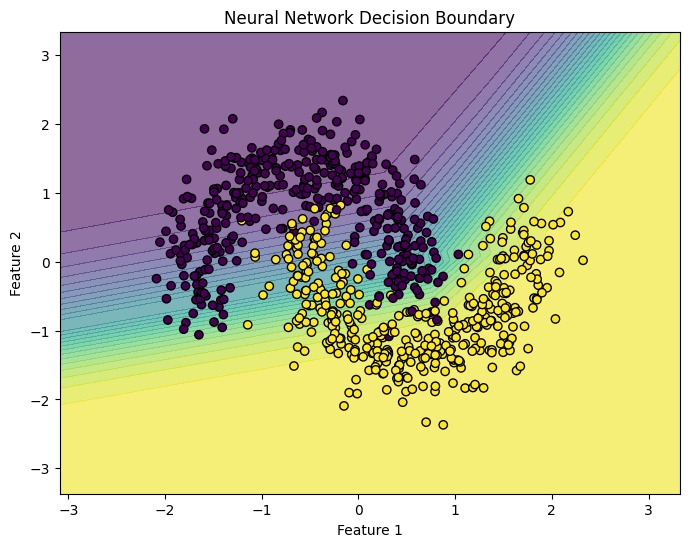

In [16]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

_, _, _, probs = forward_pass(grid)

Z = probs.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    levels=30,
    alpha=0.6
)

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    edgecolors="k"
)

plt.title("Neural Network Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

# 28. Neural Networks with PyTorch

Implementing a network manually helps us understand the mathematics.

In practical deep learning, frameworks such as PyTorch provide:

- automatic differentiation,
- tensor operations,
- GPU acceleration,
- neural-network modules,
- optimizers,
- loss functions,
- data loaders.

The conceptual workflow remains:

$$
\text{Data}
\rightarrow
\text{Model}
\rightarrow
\text{Forward Pass}
\rightarrow
\text{Loss}
\rightarrow
\text{Backward Pass}
\rightarrow
\text{Optimizer Step}
$$

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.reshape(-1, 1),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.reshape(-1, 1),
    dtype=torch.float32
)

In [21]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)


model = MLP()

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


## 29. Training with PyTorch

For binary classification we use:

$$
\operatorname{BCEWithLogitsLoss}
$$

This combines sigmoid computation and binary cross-entropy in a numerically stable implementation.

The training loop consists of:

1. Zeroing previous gradients
2. Forward pass
3. Computing loss
4. Backward pass
5. Updating parameters

In [22]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

epochs = 500

pytorch_loss_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    logits = model(X_train_tensor)

    loss = criterion(
        logits,
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    pytorch_loss_history.append(
        loss.item()
    )

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 0: Loss = 0.6920
Epoch 100: Loss = 0.1545
Epoch 200: Loss = 0.0652
Epoch 300: Loss = 0.0618
Epoch 400: Loss = 0.0595


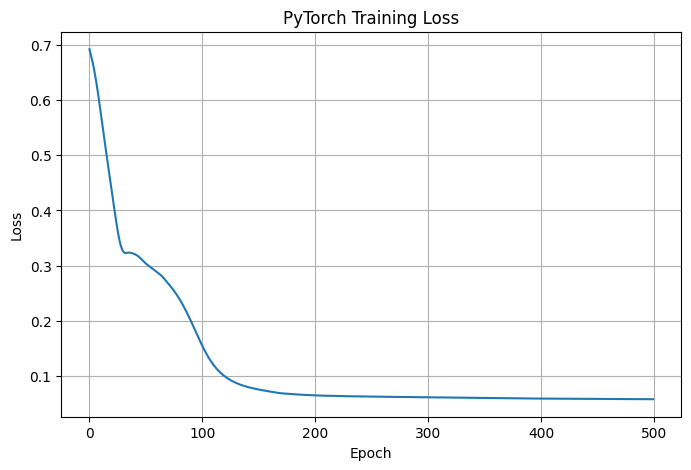

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(pytorch_loss_history)

plt.title("PyTorch Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.show()

# 30. Deep Learning Workflow

A practical deep-learning workflow can be summarized as:

$$
\boxed{
\text{Problem Definition}
\rightarrow
\text{Data Collection}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Train/Validation/Test Split}
}
$$

followed by:

$$
\boxed{
\text{Model Design}
\rightarrow
\text{Training}
\rightarrow
\text{Validation}
\rightarrow
\text{Hyperparameter Tuning}
}
$$

and finally:

$$
\boxed{
\text{Test Evaluation}
\rightarrow
\text{Error Analysis}
\rightarrow
\text{Deployment}
\rightarrow
\text{Monitoring}
}
$$

The most important principle is that **model architecture is only one part of a deep-learning system**.

# 31. Common Failure Modes

## 1. Training loss does not decrease

Possible causes:

- learning rate is inappropriate,
- incorrect gradients,
- poor initialization,
- inappropriate activation,
- incorrect preprocessing.

## 2. Training accuracy is high but validation accuracy is poor

Likely cause:

$$
\boxed{\text{Overfitting}}
$$

Possible solutions:

- more data,
- regularization,
- dropout,
- data augmentation,
- simpler architecture,
- early stopping.

## 3. Loss becomes NaN

Possible causes:

- exploding gradients,
- numerical instability,
- excessively large learning rate,
- invalid input values.

## 4. Model predicts only one class

Possible causes:

- class imbalance,
- poor initialization,
- insufficient training,
- inappropriate threshold,
- optimization problems.

## 5. Training is extremely slow

Possible causes:

- inefficient data loading,
- excessive model size,
- unsuitable batch size,
- CPU instead of GPU,
- unnecessary computation.

# 32. Important Concepts to Remember

The fundamental deep-learning pipeline is:

$$
\boxed{
X
\xrightarrow{\text{Forward}}
\hat{Y}
\xrightarrow{\text{Loss}}
L
\xrightarrow{\text{Backpropagation}}
\nabla_\theta L
\xrightarrow{\text{Optimizer}}
\theta_{\text{new}}
}
$$

The core mathematical ideas are:

$$
\boxed{
\text{Linear Algebra}
+
\text{Calculus}
+
\text{Probability}
+
\text{Optimization}
}
$$

Deep learning is therefore not simply "using neural networks".

It is the combination of:

- representation learning,
- differentiable computation,
- gradient-based optimization,
- statistical learning,
- numerical computation.

                    ┌──────────────┐
                    │     Input    │
                    └──────┬───────┘
                           ↓
                    ┌──────────────┐
                    │ Forward Pass │
                    └──────┬───────┘
                           ↓
                    ┌──────────────┐
                    │  Prediction  │
                    └──────┬───────┘
                           ↓
                    ┌──────────────┐
                    │     Loss     │
                    └──────┬───────┘
                           ↓
                    ┌──────────────┐
                    │Backpropagation│
                    └──────┬───────┘
                           ↓
                    ┌──────────────┐
                    │  Gradients   │
                    └──────┬───────┘
                           ↓
                    ┌──────────────┐
                    │  Optimizer   │
                    └──────┬───────┘
                           ↓
                    ┌──────────────┐
                    │ New Weights  │
                    └──────────────┘
                           │
                           └──────→ repeat